In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def co2_model(year):
    if year <= 1950:
        return 296.0 + 0.30 * (year - 1900)
    elif 1950 < year <= 2000:
        return 311.0 + 1.16 * (year - 1950)
    else:
        t = year - 2000
        return 369.0 + 1.85 * t + 0.018 * (t**2)

In [30]:
def calculate_depth(start_year, end_year, fck, humidity):
    years = np.arange(start_year, end_year + 1)
    depths = [0.0]
    
    # Humidity factor (worst-case scenario occurs around 65% RH)
    rh_factor = 1 - abs(humidity - 65) / 100.0
    
    # Constant adjusted for the 124-year visual scale
    constant = 550.0  
    
    current_depth_squared = 0.0
    for year in years[1:]:
        co2_pct = co2_model(year) / 1e4
        k_year = constant * rh_factor * np.sqrt(co2_pct) / fck
        
        # Accumulating the advance
        current_depth_squared += k_year**2
        depths.append(np.sqrt(current_depth_squared))
        
    return years, depths

In [31]:
start_year = 1900
end_year = 2024
concrete_cover = 30 # Warning line at 30mm

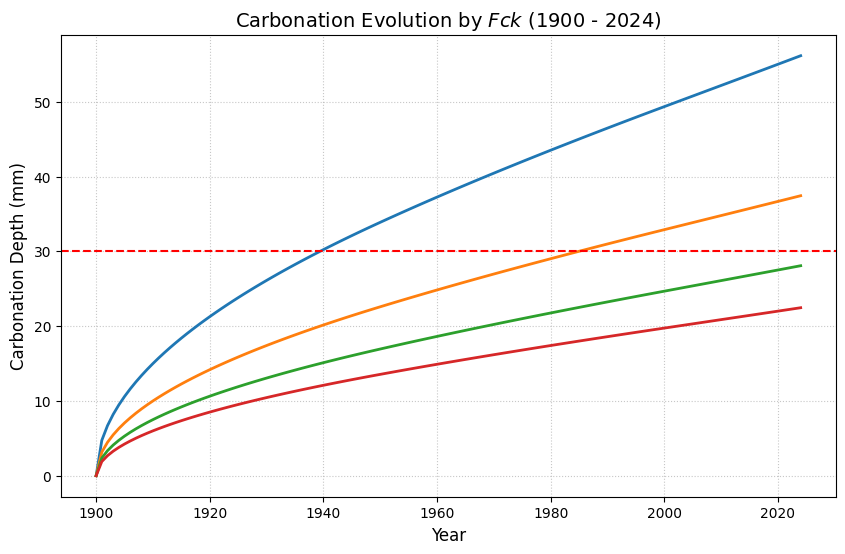

In [32]:
plt.figure(figsize=(10, 6))
fck_list = [20, 30, 40, 50]
fixed_humidity = 65

for fck in fck_list:
    years, prof = calculate_depth(start_year, end_year, fck, fixed_humidity)
    plt.plot(years, prof, linewidth=2, label=f'$f_{{ck}}$ = {fck} MPa')

plt.axhline(y=concrete_cover, color='red', linestyle='--', linewidth=1.5, label='Concrete Cover (30 mm)')
plt.title(f'Carbonation Evolution by $Fck$ (1900 - 2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Carbonation Depth (mm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('chart_1900_fck_en.png', dpi=300, bbox_inches='tight')
plt.show()

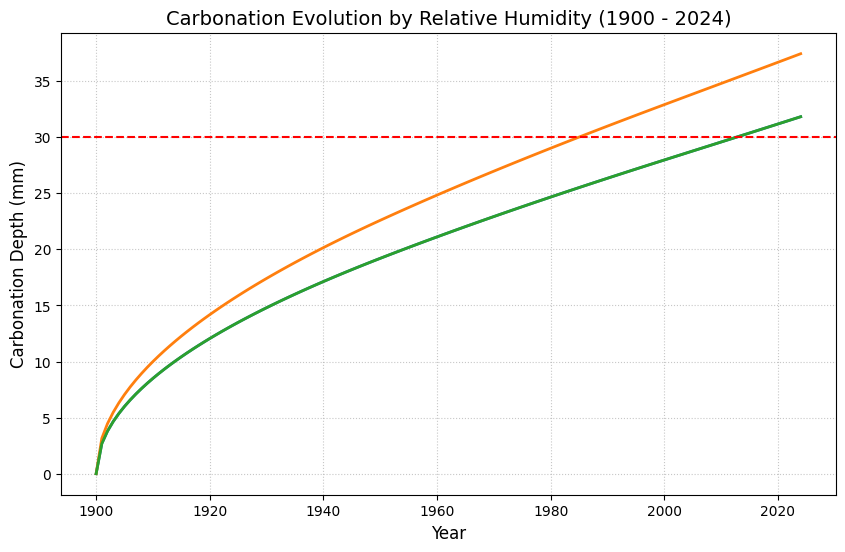

In [33]:
plt.figure(figsize=(10, 6))
fixed_fck = 30
rh_list = [50, 65, 80]

for rh in rh_list:
    years, prof = calculate_depth(start_year, end_year, fixed_fck, rh)
    plt.plot(years, prof, linewidth=2, label=f'Humidity = {rh}%')

plt.axhline(y=concrete_cover, color='red', linestyle='--', linewidth=1.5, label='Concrete Cover (30 mm)')
plt.title(f'Carbonation Evolution by Relative Humidity (1900 - 2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Carbonation Depth (mm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('chart_1900_humidity_en.png', dpi=300, bbox_inches='tight')
plt.show()

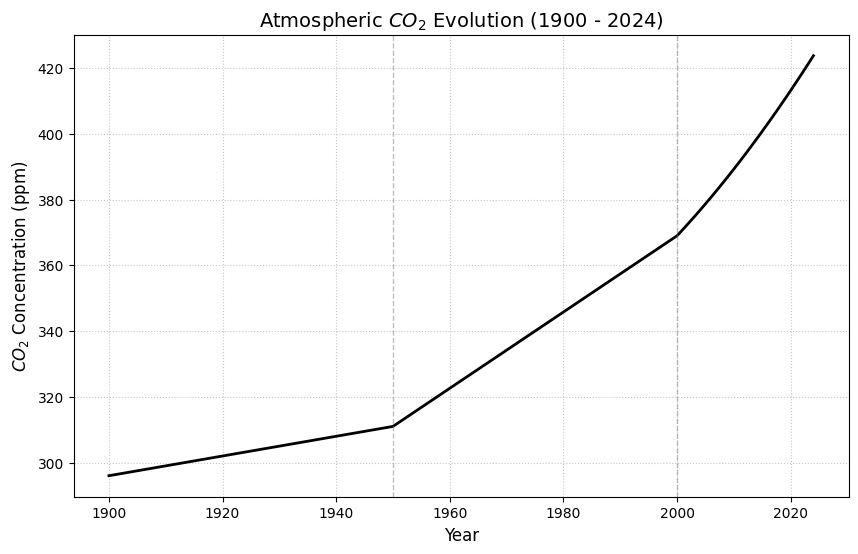

In [34]:
#CO2

years_co2 = np.arange(start_year, end_year + 1)
co2_ppm = [co2_model(y) for y in years_co2]

plt.figure(figsize=(10, 6))
plt.plot(years_co2, co2_ppm, color='black', linewidth=2, label='$CO_2$ Regression Model')
# Lines showing the division of equations (1950 and 2000)
plt.axvline(x=1950, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=2000, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Atmospheric $CO_2$ Evolution (1900 - 2024)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('$CO_2$ Concentration (ppm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig('chart_1900_co2_en.png', dpi=300, bbox_inches='tight')
plt.show()